#📌 Extracão

In [ ]:
from google.colab import drive
drive.mount('/content/drive')


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import json

caminho = '/content/drive/MyDrive/Colab Notebooks/Telecom X/TelecomX_Data.json'

with open(caminho) as f:
    dados_brutos = json.load(f)

type(dados_brutos)

list

In [ ]:
import pandas as pd  # Importa a biblioteca pandas

# Converte a lista de dicionários em DataFrame
df = pd.DataFrame(dados_brutos)

# Visualiza as primeiras linhas
df.head()


,customerID,Churn,customer,phone,internet,account
0,0002-ORFBO,No,"{'gender': 'Female', 'SeniorCitizen': 0, 'Part...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'DSL', 'OnlineSecurity': '...","{'Contract': 'One year', 'PaperlessBilling': '..."
1,0003-MKNFE,No,"{'gender': 'Male', 'SeniorCitizen': 0, 'Partne...","{'PhoneService': 'Yes', 'MultipleLines': 'Yes'}","{'InternetService': 'DSL', 'OnlineSecurity': '...","{'Contract': 'Month-to-month', 'PaperlessBilli..."
2,0004-TLHLJ,Yes,"{'gender': 'Male', 'SeniorCitizen': 0, 'Partne...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'Fiber optic', 'OnlineSecu...","{'Contract': 'Month-to-month', 'PaperlessBilli..."
3,0011-IGKFF,Yes,"{'gender': 'Male', 'SeniorCitizen': 1, 'Partne...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'Fiber optic', 'OnlineSecu...","{'Contract': 'Month-to-month', 'PaperlessBilli..."
4,0013-EXCHZ,Yes,"{'gender': 'Female', 'SeniorCitizen': 1, 'Part...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'Fiber optic', 'OnlineSecu...","{'Contract': 'Month-to-month', 'PaperlessBilli..."


#🔧 Transformação

In [ ]:
df.info()  # Mostra tipos de dados e colunas


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7267 entries, 0 to 7266
Data columns (total 6 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   customerID  7267 non-null   object
 1   Churn       7267 non-null   object
 2   customer    7267 non-null   object
 3   phone       7267 non-null   object
 4   internet    7267 non-null   object
 5   account     7267 non-null   object
dtypes: object(6)
memory usage: 340.8+ KB


In [ ]:
# Achata toda a estrutura do JSON de uma vez
df_transformado = pd.json_normalize(dados_brutos)

# Visualiza as primeiras linhas
df_transformado.head()

,customerID,Churn,customer.gender,customer.SeniorCitizen,customer.Partner,customer.Dependents,customer.tenure,phone.PhoneService,phone.MultipleLines,internet.InternetService,...,internet.OnlineBackup,internet.DeviceProtection,internet.TechSupport,internet.StreamingTV,internet.StreamingMovies,account.Contract,account.PaperlessBilling,account.PaymentMethod,account.Charges.Monthly,account.Charges.Total
0,0002-ORFBO,No,Female,0,Yes,Yes,9,Yes,No,DSL,...,Yes,No,Yes,Yes,No,One year,Yes,Mailed check,65.6,593.3
1,0003-MKNFE,No,Male,0,No,No,9,Yes,Yes,DSL,...,No,No,No,No,Yes,Month-to-month,No,Mailed check,59.9,542.4
2,0004-TLHLJ,Yes,Male,0,No,No,4,Yes,No,Fiber optic,...,No,Yes,No,No,No,Month-to-month,Yes,Electronic check,73.9,280.85
3,0011-IGKFF,Yes,Male,1,Yes,No,13,Yes,No,Fiber optic,...,Yes,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,98.0,1237.85
4,0013-EXCHZ,Yes,Female,1,Yes,No,3,Yes,No,Fiber optic,...,No,No,Yes,Yes,No,Month-to-month,Yes,Mailed check,83.9,267.4


In [ ]:
# Verificando estrutura do dataset e tipos de dados
df_transformado.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7267 entries, 0 to 7266
Data columns (total 21 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   customerID                 7267 non-null   object 
 1   Churn                      7267 non-null   object 
 2   customer.gender            7267 non-null   object 
 3   customer.SeniorCitizen     7267 non-null   int64  
 4   customer.Partner           7267 non-null   object 
 5   customer.Dependents        7267 non-null   object 
 6   customer.tenure            7267 non-null   int64  
 7   phone.PhoneService         7267 non-null   object 
 8   phone.MultipleLines        7267 non-null   object 
 9   internet.InternetService   7267 non-null   object 
 10  internet.OnlineSecurity    7267 non-null   object 
 11  internet.OnlineBackup      7267 non-null   object 
 12  internet.DeviceProtection  7267 non-null   object 
 13  internet.TechSupport       7267 non-null   objec

In [ ]:
# Observação:
# A maioria das colunas está como object.
# A coluna 'account_charges_total' está como object,
# embora represente valores numéricos.
# Será necessário converter para tipo float.


In [ ]:
# Substitui ponto por underline
df_transformado.columns = df_transformado.columns.str.replace('.', '_')

# Verifica resultado
df_transformado.columns


Index(['customerID', 'Churn', 'customer_gender', 'customer_SeniorCitizen',
       'customer_Partner', 'customer_Dependents', 'customer_tenure',
       'phone_PhoneService', 'phone_MultipleLines', 'internet_InternetService',
       'internet_OnlineSecurity', 'internet_OnlineBackup',
       'internet_DeviceProtection', 'internet_TechSupport',
       'internet_StreamingTV', 'internet_StreamingMovies', 'account_Contract',
       'account_PaperlessBilling', 'account_PaymentMethod',
       'account_Charges_Monthly', 'account_Charges_Total'],
      dtype='object')

In [ ]:
# Verificando alguns valores únicos da coluna 'account_charges_total', para entender seu formato e identificar possíveis inconsistências
df_transformado['account_Charges_Total'].unique()[:10]


array(['593.3', '542.4', '280.85', '1237.85', '267.4', '571.45',
       '7904.25', '5377.8', '340.35', '5957.9'], dtype=object)

In [ ]:
# Converte para numérico, caso exista algum valor estranho vira NaN
df_transformado['account_Charges_Total'] = pd.to_numeric(
    df_transformado['account_Charges_Total'],
    errors='coerce'
)

# Verifica o tipo depois da conversão
df_transformado['account_Charges_Total'].dtype


dtype('float64')

In [ ]:
df_transformado['account_Charges_Total'].isnull().sum() #verificar se surgiram valores nulos


np.int64(11)

In [ ]:
# Filtra apenas os registros onde TotalCharges é nulo
df_transformado[df_transformado['account_Charges_Total'].isnull()]


,customerID,Churn,customer_gender,customer_SeniorCitizen,customer_Partner,customer_Dependents,customer_tenure,phone_PhoneService,phone_MultipleLines,internet_InternetService,...,internet_OnlineBackup,internet_DeviceProtection,internet_TechSupport,internet_StreamingTV,internet_StreamingMovies,account_Contract,account_PaperlessBilling,account_PaymentMethod,account_Charges_Monthly,account_Charges_Total
975,1371-DWPAZ,No,Female,0,Yes,Yes,0,No,No phone service,DSL,...,Yes,Yes,Yes,Yes,No,Two year,No,Credit card (automatic),56.05,NaN
1775,2520-SGTTA,No,Female,0,Yes,Yes,0,Yes,No,No,...,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.00,NaN
1955,2775-SEFEE,No,Male,0,No,Yes,0,Yes,Yes,DSL,...,Yes,No,Yes,No,No,Two year,Yes,Bank transfer (automatic),61.90,NaN
2075,2923-ARZLG,No,Male,0,Yes,Yes,0,Yes,No,No,...,No internet service,No internet service,No internet service,No internet service,No internet service,One year,Yes,Mailed check,19.70,NaN
2232,3115-CZMZD,No,Male,0,No,Yes,0,Yes,No,No,...,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.25,NaN
2308,3213-VVOLG,No,Male,0,Yes,Yes,0,Yes,Yes,No,...,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.35,NaN
2930,4075-WKNIU,No,Female,0,Yes,Yes,0,Yes,Yes,DSL,...,Yes,Yes,Yes,Yes,No,Two year,No,Mailed check,73.35,NaN
3134,4367-NUYAO,No,Male,0,Yes,Yes,0,Yes,Yes,No,...,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.75,NaN
3203,4472-LVYGI,No,Female,0,Yes,Yes,0,No,No phone service,DSL,...,No,Yes,Yes,Yes,No,Two year,Yes,Bank transfer (automatic),52.55,NaN
4169,5709-LVOEQ,No,Female,0,Yes,Yes,0,Yes,No,DSL,...,Yes,Yes,No,Yes,Yes,Two year,No,Mailed check,80.85,NaN


In [ ]:
# Substitui os NaN por 0
df_transformado['account_Charges_Total'] = df_transformado['account_Charges_Total'].fillna(0)

# Verifica novamente valores nulos
df_transformado.isnull().sum()


,0
customerID,0
Churn,0
customer_gender,0
customer_SeniorCitizen,0
customer_Partner,0
customer_Dependents,0
customer_tenure,0
phone_PhoneService,0
phone_MultipleLines,0
internet_InternetService,0


In [ ]:
df_transformado.columns = df_transformado.columns.str.lower() #Padronizar nomes de colunas
df_transformado['churn'].value_counts() #Verificar variável alvo (Churn)


,count
churn,
No,5174
Yes,1869
,224


In [ ]:
df_transformado['churn'].unique() # Verificando valores únicos da coluna churn

array(['No', 'Yes', ''], dtype=object)

In [ ]:
df_transformado[df_transformado['churn'] == ''].head() #Mostra as primeiras linhas onde churn está vazio


,customerid,churn,customer_gender,customer_seniorcitizen,customer_partner,customer_dependents,customer_tenure,phone_phoneservice,phone_multiplelines,internet_internetservice,...,internet_onlinebackup,internet_deviceprotection,internet_techsupport,internet_streamingtv,internet_streamingmovies,account_contract,account_paperlessbilling,account_paymentmethod,account_charges_monthly,account_charges_total
30,0047-ZHDTW,,Female,0,No,No,11,Yes,Yes,Fiber optic,...,No,No,No,No,No,Month-to-month,Yes,Bank transfer (automatic),79.00,929.30
75,0120-YZLQA,,Male,0,No,No,71,Yes,No,No,...,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,Yes,Credit card (automatic),19.90,1355.10
96,0154-QYHJU,,Male,0,No,No,29,Yes,No,DSL,...,Yes,No,Yes,No,No,One year,Yes,Electronic check,58.75,1696.20
98,0162-RZGMZ,,Female,1,No,No,5,Yes,No,DSL,...,Yes,No,Yes,No,No,Month-to-month,No,Credit card (automatic),59.90,287.85
175,0274-VVQOQ,,Male,1,Yes,No,65,Yes,Yes,Fiber optic,...,Yes,Yes,No,Yes,Yes,One year,Yes,Bank transfer (automatic),103.15,6792.45


In [ ]:
df_transformado[df_transformado['churn'] == ''].shape # Contando quantos registros possuem churn vazio


(224, 21)

In [ ]:
# Removendo registros com churn vazio
df_transformado = df_transformado[df_transformado['churn'] != '']
# Removemos 224 registros com churn vazio,pois não é possível determinar corretamente, se o cliente cancelou ou não.

In [ ]:
df_transformado.duplicated().sum() # Verificando registros duplicados


np.int64(0)

In [ ]:
df_transformado['churn'].value_counts()


,count
churn,
No,5174
Yes,1869


In [ ]:
# Dataset final pronto para análise
df_transformado.info()


<class 'pandas.core.frame.DataFrame'>
Index: 7043 entries, 0 to 7266
Data columns (total 21 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   customerid                 7043 non-null   object 
 1   churn                      7043 non-null   object 
 2   customer_gender            7043 non-null   object 
 3   customer_seniorcitizen     7043 non-null   int64  
 4   customer_partner           7043 non-null   object 
 5   customer_dependents        7043 non-null   object 
 6   customer_tenure            7043 non-null   int64  
 7   phone_phoneservice         7043 non-null   object 
 8   phone_multiplelines        7043 non-null   object 
 9   internet_internetservice   7043 non-null   object 
 10  internet_onlinesecurity    7043 non-null   object 
 11  internet_onlinebackup      7043 non-null   object 
 12  internet_deviceprotection  7043 non-null   object 
 13  internet_techsupport       7043 non-null   object 
 1

In [ ]:
caminho_saida = '/content/drive/MyDrive/Colab Notebooks/Telecom X/telecom_tratado.csv'

df_transformado.to_csv(caminho_saida, index=False)

print("Dataset tratado salvo com sucesso!")


Dataset tratado salvo com sucesso!


#📊 Carga e análise

In [ ]:
df_transformado.describe()


,customer_seniorcitizen,customer_tenure,account_charges_monthly,account_charges_total
count,7043.000000,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692,2279.734304
std,0.368612,24.559481,30.090047,2266.794470
min,0.000000,0.000000,18.250000,0.000000
25%,0.000000,9.000000,35.500000,398.550000
50%,0.000000,29.000000,70.350000,1394.550000
75%,0.000000,55.000000,89.850000,3786.600000
max,1.000000,72.000000,118.750000,8684.800000


In [ ]:
df_transformado.mean(numeric_only=True) #Média


,0
customer_seniorcitizen,0.162147
customer_tenure,32.371149
account_charges_monthly,64.761692
account_charges_total,2279.734304


In [ ]:
df_transformado.median(numeric_only=True) #mediana


,0
customer_seniorcitizen,0.00
customer_tenure,29.00
account_charges_monthly,70.35
account_charges_total,1394.55


In [ ]:
df_transformado.std(numeric_only=True) #desvio padrão

,0
customer_seniorcitizen,0.368612
customer_tenure,24.559481
account_charges_monthly,30.090047
account_charges_total,2266.794470


In [ ]:
import matplotlib.pyplot as plt  # Importa a biblioteca responsável por criar gráficos


In [ ]:
df_transformado["churn"].value_counts() # Conta quantas vezes aparece 0 e quantas vezes aparece 1 na coluna churn

,count
churn,
No,5174
Yes,1869


In [ ]:
churn_percent = df_transformado["churn"].value_counts(normalize=True) * 100  # normalize=True transforma em proporção, * 100 transforma em porcentagem
churn_percent

,proportion
churn,
No,73.463013
Yes,26.536987


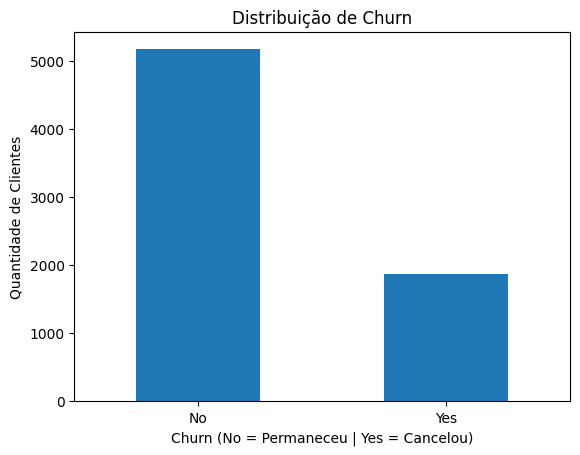

In [ ]:
plt.figure()
# Cria uma nova "área" de gráfico

df_transformado["churn"].value_counts().plot(kind="bar")
# Cria o gráfico de barras

plt.title("Distribuição de Churn")
# Define o título

plt.xlabel("Churn (No = Permaneceu | Yes = Cancelou)")
# Nome do eixo X (agora corrigido para seus valores reais)

plt.ylabel("Quantidade de Clientes")
# Nome do eixo Y

plt.xticks(rotation=0)
# Deixa os nomes retos

plt.show()
# Exibe o gráfico final


In [ ]:
churn_percent = df_transformado["churn"].value_counts(normalize=True) * 100
# value_counts(normalize=True) calcula a proporção
# multiplicamos por 100 para virar porcentagem


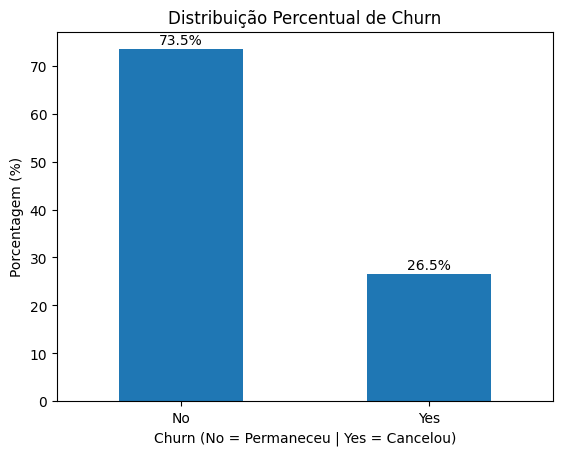

In [ ]:
plt.figure()
# Cria uma nova área de gráfico

churn_percent.plot(kind="bar")
# Cria o gráfico de barras usando os valores percentuais

plt.title("Distribuição Percentual de Churn")
# Título

plt.xlabel("Churn (No = Permaneceu | Yes = Cancelou)")
# Nome eixo X

plt.ylabel("Porcentagem (%)")
# Agora o eixo Y é porcentagem

plt.xticks(rotation=0)
# Mantém os rótulos retos

for i, valor in enumerate(churn_percent):
    plt.text(i, valor + 1, f"{valor:.1f}%", ha='center')
# i = posição da barra (0 ou 1)
# valor = valor da porcentagem
# valor + 1 = posiciona o texto um pouco acima da barra
# f"{valor:.1f}%" formata com 1 casa decimal
# ha='center' centraliza o texto



In [ ]:
#Observa-se que 73,46% dos clientes permaneceram na empresa, enquanto 26,53% realizaram churn.
#Embora a maioria esteja retida, a taxa de evasão representa mais de um quarto da base, indicando oportunidade de melhoria nas estratégias de retenção.

In [ ]:
pd.crosstab(df_transformado["customer_gender"], df_transformado["churn"])
# Cria uma tabela cruzando gênero com churn
# Mostra quantidade de homens/mulheres que cancelaram ou não


churn,No,Yes
customer_gender,,
Female,2549,939
Male,2625,930


In [ ]:
pd.crosstab(
    df_transformado["customer_gender"],
    df_transformado["churn"],
    normalize="index"
) * 100
# normalize="index" calcula porcentagem dentro de cada linha
# * 100 transforma em %


churn,No,Yes
customer_gender,,
Female,73.079128,26.920872
Male,73.839662,26.160338


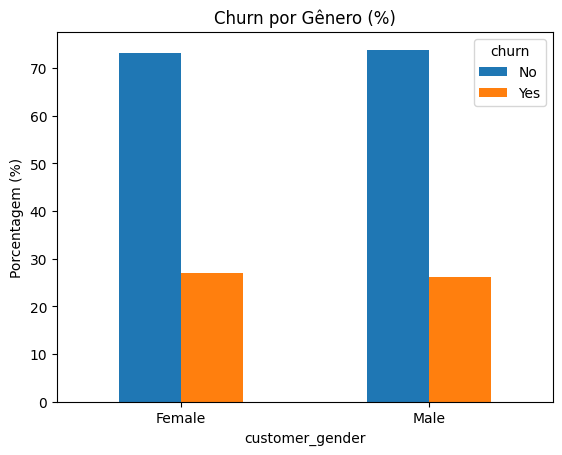

In [ ]:
tabela_genero = pd.crosstab(
    df_transformado["customer_gender"],
    df_transformado["churn"],
    normalize="index"
) * 100
# Cria a tabela percentual

tabela_genero.plot(kind="bar")
# Cria gráfico de barras agrupadas

plt.title("Churn por Gênero (%)")
plt.ylabel("Porcentagem (%)")
plt.xticks(rotation=0)
plt.show()


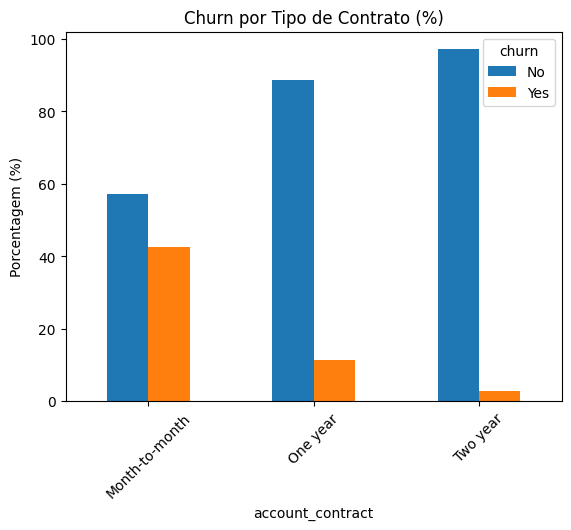

In [ ]:
tabela_contrato = pd.crosstab(
    df_transformado["account_contract"],
    df_transformado["churn"],
    normalize="index"
) * 100

tabela_contrato.plot(kind="bar")

plt.title("Churn por Tipo de Contrato (%)")
plt.ylabel("Porcentagem (%)")
plt.xticks(rotation=45)
plt.show()


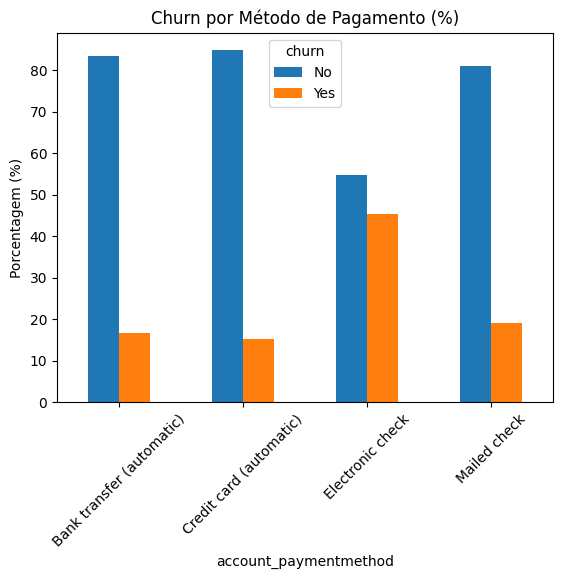

In [ ]:
tabela_pagamento = pd.crosstab(
    df_transformado["account_paymentmethod"],
    df_transformado["churn"],
    normalize="index"
) * 100

tabela_pagamento.plot(kind="bar")

plt.title("Churn por Método de Pagamento (%)")
plt.ylabel("Porcentagem (%)")
plt.xticks(rotation=45)
plt.show()


In [ ]:
#Observa-se que clientes com contrato mensal apresentam taxa de churn significativamente superior aos demais tipos de contrato, indicando menor fidelização nesse modelo.

#Além disso, o método de pagamento "Electronic Check" apresentou percentual de evasão consideravelmente maior quando comparado a cartão de crédito, débito automático ou cheque enviado por correio.

#Esse padrão pode indicar maior sensibilidade a preço, menor vínculo contratual ou possíveis fricções no processo de pagamento, sugerindo oportunidade de atuação estratégica para retenção nesse segmento.

In [ ]:
pd.crosstab(
    [df_transformado["account_contract"], df_transformado["account_paymentmethod"]],
    df_transformado["churn"],
    normalize="index"
) * 100


churn                                              No        Yes
account_contract account_paymentmethod                          
Month-to-month   Bank transfer (automatic)  65.874363  34.125637
                 Credit card (automatic)    67.219153  32.780847
                 Electronic check           46.270270  53.729730
                 Mailed check               68.421053  31.578947
One year         Bank transfer (automatic)  90.281330   9.718670
                 Credit card (automatic)    89.698492  10.301508
                 Electronic check           81.556196  18.443804
                 Mailed check               93.175074   6.824926
Two year         Bank transfer (automatic)  96.631206   3.368794
                 Credit card (automatic)    97.762478   2.237522
                 Electronic check           92.261905   7.738095
                 Mailed check               99.214660   0.785340

In [ ]:
df_transformado.groupby("churn")[
    ["customer_tenure", "account_charges_monthly", "account_charges_total"]
].mean()
# Agrupa por churn
# Seleciona apenas as colunas numéricas
# Calcula a média de cada grupo


,customer_tenure,account_charges_monthly,account_charges_total
churn,,,
No,37.569965,61.265124,2549.911442
Yes,17.979133,74.441332,1531.796094


In [ ]:
df_transformado.groupby("churn")[
    ["customer_tenure", "account_charges_monthly", "account_charges_total"]
].median()
# Calcula a mediana para cada grupo


,customer_tenure,account_charges_monthly,account_charges_total
churn,,,
No,38.0,64.425,1679.525
Yes,10.0,79.650,703.550


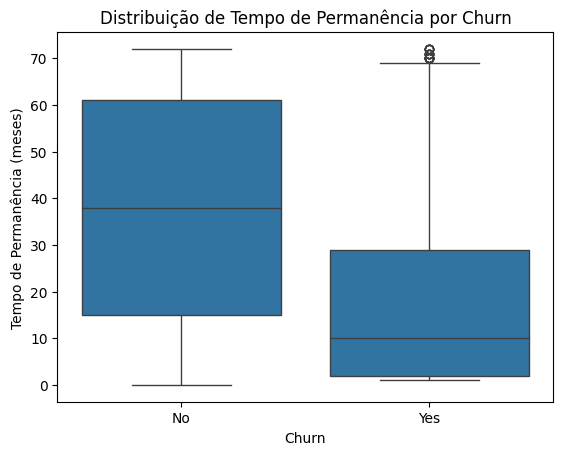

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure()
sns.boxplot(x="churn", y="customer_tenure", data=df_transformado)

plt.title("Distribuição de Tempo de Permanência por Churn")
plt.xlabel("Churn")
plt.ylabel("Tempo de Permanência (meses)")
plt.show()


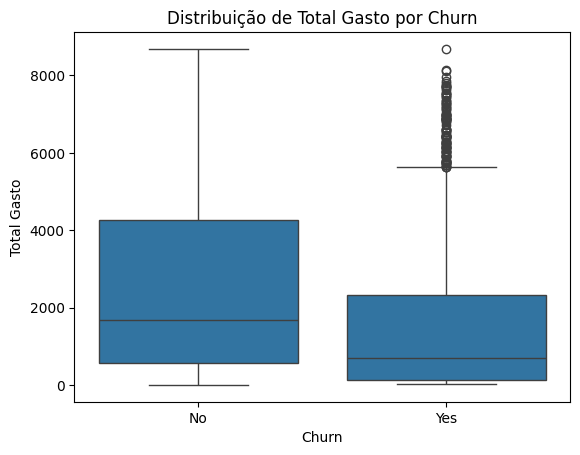

In [ ]:
plt.figure()
sns.boxplot(x="churn", y="account_charges_total", data=df_transformado)

plt.title("Distribuição de Total Gasto por Churn")
plt.xlabel("Churn")
plt.ylabel("Total Gasto")
plt.show()


#📄Relatorio Final

In [ ]:
# RELATÓRIO FINAL – Análise de Churn
# 1-Introdução

# A evasão de clientes (Churn) representa um dos principais desafios para empresas de serviços recorrentes, pois impacta diretamente a receita e a sustentabilidade do negócio.
# O objetivo desta análise foi investigar os fatores associados ao cancelamento de clientes, identificando padrões comportamentais e características que possam estar relacionadas à maior probabilidade de evasão.
# Através de técnicas de análise exploratória de dados (EDA), buscamos compreender quais variáveis influenciam o churn e gerar insights que possam apoiar estratégias de retenção.

# 2- Limpeza e Tratamento de Dados

# Durante a preparação dos dados, foram realizados os seguintes passos:
# Importação do dataset para o ambiente Python.
# Verificação de valores ausentes.
# Conversão de colunas numéricas (como TotalCharges) para o tipo adequado.
# Tratamento de inconsistências nos dados.
# Padronização de variáveis categóricas.
# Criação de tabelas agregadas para cálculo de taxas de churn por categoria.
# Essas etapas garantiram que os dados estivessem consistentes e prontos para análise.

# 4 Análise Exploratória de Dados (EDA)
# Foram realizadas diversas análises para identificar padrões relacionados à evasão.

# > Distribuição Geral de Churn
# Foi observado que uma parcela significativa dos clientes realiza cancelamento, indicando oportunidade para estratégias de retenção.

# >  Tipo de Contrato
# Clientes com contrato Month-to-month apresentaram taxas de evasão significativamente maiores em comparação com contratos de One year e Two year.
# Isso indica que contratos de longo prazo estão fortemente associados à retenção.

# > Método de Pagamento
# O método Electronic Check apresentou a maior taxa de churn, especialmente entre clientes com contrato mensal.
# Isso sugere possível associação entre:

# Perfil de cliente
# Forma de pagamento
# Maior propensão ao cancelamento

# > Total Gasto (TotalCharges)
# Clientes que cancelaram tendem a apresentar menor gasto total acumulado, sugerindo menor tempo de permanência.
# Entretanto, foram identificados alguns clientes com alto gasto que também cancelaram, indicando que churn não ocorre apenas em clientes novos.

# > Tempo de Permanência (Tenure)
# A análise mostrou que clientes com menor tempo de contrato apresentam maior probabilidade de churn.
# Isso reforça que o risco de evasão é maior nos primeiros meses de relacionamento.


# 4 Conclusões e Insights:
# A análise revelou padrões claros:

# - Clientes com contrato mensal apresentam maior evasão.

# - O método Electronic Check está associado a maiores taxas de churn.

# - O risco de cancelamento é maior nos primeiros meses.

# - Clientes que permanecem mais tempo acumulam maior gasto e tendem a cancelar menos.

# Esses resultados indicam que churn está fortemente ligado a:
# Tipo de contrato
# Forma de pagamento
# Tempo de permanência

# 5 Recomendações
# Com base na análise, recomenda-se:

# - Incentivar a migração de contratos mensais para contratos anuais com descontos ou benefícios.
# - Investigar a experiência de clientes que utilizam Electronic Check, avaliando possíveis fricções no processo de pagamento.
# - Implementar ações de retenção nos primeiros meses de contrato, como:
# - Contato proativo
# - Benefícios iniciais
# - Programas de fidelização
# - Criar um modelo preditivo de churn para identificar clientes com alto risco e agir preventivamente.


In [ ]:
df_transformado.to_csv(
    '/content/drive/MyDrive/Colab Notebooks/Telecom X/telecom_tratado.csv',
    index=False
)
